# Advanced topics

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  18/07/2025  
**Last modified:**  05/04/2026

## 1. Introduction

Advanced tricks and topics are reviewed here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from methods.exxoep import EXXOEP
from methods.osexxoep import OSEXXOEP
from methods.osdftoep import OSDFTOEP
from pyscf import gto, dft, scf
from utils.coulomb_potential_on_grid import coulomb_potential_on_grid
from utils.gen_coords_1d import gen_coords_1d

In [2]:
# Function to make text in bold
def bold_text(text): return "\033[1m" + text + "\033[0m"

def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues, HOMO energy, and LUMO-HOMO gap.
    
    Args:
      eig: Eigenvalues.
      no: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    if len(eigs.shape) == 1:  # closed-shell case
        for i in range(nmax):
            eig = f"{eigs[i]:7.3f}"
            if i+1 <= no:
                eig = bold_text(eig)
            print(f"{i+1:2}   {eig}")
        print(f"HOMO:      {eigs[no-1]:7.3f}")
        print(f"LUMO-HOMO: {eigs[no]-eigs[no-1]:7.3f}")
    else:
        for i in range(nmax):
            ea = f"{eigs[0, i]:7.3f}"
            eb = f"{eigs[1, i]:7.3f}"
            if i+1 <= no[0]: 
                ea = bold_text(ea)
            if i+1 <= no[1]:
                eb = bold_text(eb)            
            if i+1 <= nmax:
                print(f"{i+1:2}   {ea}  {eb}")
        print(f"HOMO:       {eigs[0, no[0]-1]:7.3f}   {eigs[1, no[1]-1]:7.3f}")
        print(f"LUMO-HOMO:  {eigs[0, no[0]] - eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1]] - eigs[1, no[1] - 1]:7.3f}")

## 2. Counteraction of electric field by EXX-OEP: example of hydrogen chain
> E. Trushin, R. Mandalia, A. Görling. Analyzing the response of exchange–correlation potentials of chain-like molecules to electric fields by Kohn–Sham inversion and evaluation of the response within the random phase approximation -- J. Chem. Phys. 163, 244115 (2025). https://doi.org/10.1063/5.0294687

In [3]:
def hydrogen_chain(n_mols, r1=1.058354498, r2=1.587531747, centered=True):
    r"""
    Creates list with coordinates of hydrogen atoms.

    Args:
        n_mols: number of h2 molecules
        r1: itermolecular bond length
        r2: intramolecular bond length
        centered: detemines whether geometry is centered with respect to z=0 or not
    """
    z = [0.0]
    for i in range(n_mols):
        z.append(z[-1] + r1)
        z.append(z[-1] + r2)
    z.pop()  # remove last element

    if centered:
        shift = z[-1] / 2.0
        for i in range(len(z)):
            z[i] -= shift

    return z


def hydrogen_chain_pyscf(n_mols, r1=1.058354498, r2=1.587531747, centered=True):
    r"""
    Creates text with geometry to use in PySCF.

    Args:
        n_mols: number of h2 molecules
        r1: itermolecular bond length
        r2: intramolecular bond length
        centered: detemines whether geometry is centered with respect to z=0 or not
    """

    z = hydrogen_chain(n_mols, r1, r2, centered)

    geom = ""
    for x in z:
        geom += f"H 0. 0. {x}; "

    return geom[:-2]

In [4]:
def lda_vxc(mol, coords, dm, xc):
    """Evaluate the LDA exchange-correlation potential on a given real-space grid.

    Args:
      mol: PySCF molecule object
      coords: coordinates of grid on which the potential will be calculated
      dm: density matrix
      xc: xc string, i.e. xc='lda'

    Returns:
      vxc: exchange-correlation potential on grid
    """
    ao_value = dft.numint.eval_ao(mol, coords, deriv=0)
    rho = dft.numint.eval_rho(mol, ao_value, dm, xctype="LDA")
    _, vxc = dft.libxc.eval_xc(xc, rho)[:2]
    return vxc[0]

In [5]:
N_MOLS = 3
ELECTRIC_FIELD = [0., 0., -0.001]
coords = gen_coords_1d(-25., 25., 1000)

In [6]:
mol = gto.M(atom=hydrogen_chain_pyscf(n_mols=N_MOLS), basis="aug-cc-pVQZ", symmetry=False)
mol.verbose = 0

# LDA calculation without field
mf = dft.RKS(mol, xc="LDA, VWN").density_fit().run()
dm = mf.make_rdm1()
vxc_lda_without_field = lda_vxc(mol, coords, dm, "LDA, VWN")

# LDA calculation with field
mf = dft.RKS(mol, xc="LDA, VWN").density_fit()
field = np.einsum("x,xij->ij", ELECTRIC_FIELD, mol.intor("int1e_r"))
h1 = mf.get_hcore() + field
mf.get_hcore = lambda *args, **kwargs: h1
mf.run()
dm = mf.make_rdm1()
vxc_lda_with_field = lda_vxc(mol, coords, dm, "LDA, VWN")

In [7]:
mol = gto.M(atom=hydrogen_chain_pyscf(n_mols=N_MOLS), basis="aug-cc-pV6Z", symmetry=False)
mol.verbose = 0

# EXX-OEP calculation without field

mf = scf.RHF(mol).density_fit().run()

mf_oep = EXXOEP(mf, "aug-cc-pVDZ-RIFIT")
mf_oep.run(maxit=15, thr_fai_oep=1e-3)

vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vx_on_grid_without_field = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

# EXX-OEP calculation with field

mf = scf.RHF(mol).density_fit()
field = np.einsum("x,xij->ij", ELECTRIC_FIELD, mol.intor("int1e_r"))
h1 = mf.get_hcore() + field
mf.get_hcore = lambda *args, **kwargs: h1
mf.run()

mf_oep = EXXOEP(mf, "aug-cc-pVDZ-RIFIT")
mf_oep.run(maxit=15, thr_fai_oep=1e-3)

vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vx_on_grid_with_field = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

ITER        ENERGY               EDIFF
  0     -3.259535792122
  1     -3.259657466351     -0.000121674229
  2     -3.259667275617     -0.000009809266
  3     -3.259669669017     -0.000002393400
  4     -3.259669688553     -0.000000019536
  5     -3.259669695192     -0.000000006639
SCF converged
ITER        ENERGY               EDIFF
  0     -3.259564068407
  1     -3.259685728178     -0.000121659771
  2     -3.259695543220     -0.000009815043
  3     -3.259697935681     -0.000002392461
  4     -3.259697955242     -0.000000019561
  5     -3.259697961867     -0.000000006625
SCF converged


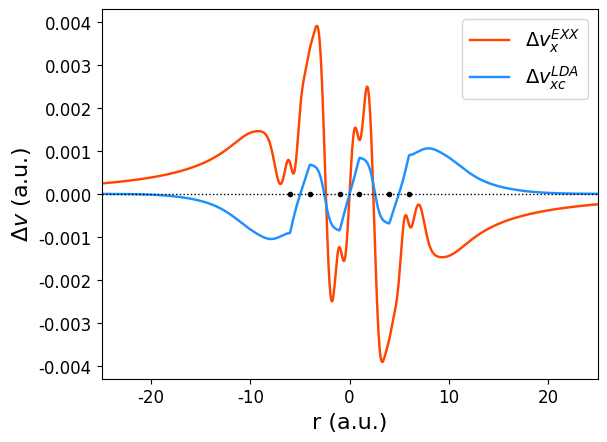

In [8]:
plt.plot(coords[:, 2], vx_on_grid_without_field-vx_on_grid_with_field, color="orangered", label="$\\Delta v_x^{EXX}$")
plt.plot(coords[:, 2], vxc_lda_without_field-vxc_lda_with_field, color="dodgerblue", label="$\\Delta v_{xc}^{LDA}$")
plt.axhline(y = 0., color = 'k', linestyle = ':', linewidth=1)
atoms = hydrogen_chain(N_MOLS, r1=2, r2=3)
plt.plot(atoms, len(atoms)*[0.], "o", color="black", markersize=3)
plt.xlim(-25, 25)
plt.ylabel("$\\Delta v$ (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

## 3. Example of obtaining an EXX-OEP solution for an oxygen atom that violates the $v$-representability condition in the spin-restricted case
> E. Trushin, J. Erhard, A. Görling. Violations of the $v$-representability condition underlying Kohn-Sham density-functional theory -- Phys. Rev. A 110 (2024) L020802. https://doi.org/10.1103/PhysRevA.110.L020802

In [9]:
class OSEXXOEP_with_swap(OSEXXOEP):
    """OSEXXOEP with swap of 3rd and 5th orbitals in beta spin-channel."""

    def get_energies_and_potentials(self):
        """Determines energy contributions and potentials."""

        self.mf.mo_coeff[1, :, 2], self.mf.mo_coeff[1, :, 4] = self.mf.mo_coeff[1, :, 4], self.mf.mo_coeff[1, :, 2]
        self.mf.mo_energy[1, 2], self.mf.mo_energy[1, 4] = self.mf.mo_energy[1, 4], self.mf.mo_energy[1, 2]

        dm = self.mf.make_rdm1()
        h1e = self.mf.get_hcore()
        e1 = np.einsum("ij,ji->", h1e, dm[0]).real
        e1 += np.einsum("ij,ji->", h1e, dm[1]).real
        self.vj_ao, self.vxnl_ao = self.mf.get_jk(dm)

        self.vj_ao = self.vj_ao[0] + self.vj_ao[1]
        self.E_Coul = np.einsum("ij,ji->", self.vj_ao, dm[0] + dm[1]).real * 0.5
        self.E_x = -0.5 * np.einsum("ij,ji->", self.vxnl_ao[0], dm[0]).real
        self.E_x += -0.5 * np.einsum("ij,ji->", self.vxnl_ao[1], dm[1]).real
        self.e_tot = e1 + self.E_Coul + self.E_x + self.mf.energy_nuc()
        self.vxnl_ao *= -1.0

In [10]:
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"
GEOM = "O 0.000000    0.000000  0.000000"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=2)
mol.verbose = 0
mol.symmetry = False

mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

mf_oep = OSEXXOEP_with_swap(mf, OEP_BASIS, spin_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2, e_conv_thr=1e-12)

print_eigs(mf_oep.mf.mo_energy, mf_oep.mf.nelec, 10)

ITER        ENERGY               EDIFF
  0    -74.730865551944
  1    -74.803755892745     -0.072890340801
  2    -74.806466394941     -0.002710502196
  3    -74.806436776877      0.000029618064
  4    -74.806498577667     -0.000061800790
  5    -74.806496598728      0.000001978939
  6    -74.806496636623     -0.000000037895
  7    -74.806496632732      0.000000003891
  8    -74.806496632947     -0.000000000215
  9    -74.806496632945      0.000000000002
 10    -74.806496632948     -0.000000000003
 11    -74.806496632947      0.000000000000
SCF converged
 1   -19.174  -19.174
 2    -1.118   -1.118
 3    -0.569   -0.532
 4    -0.569   -0.569
 5    -0.532   -0.569
 6    -0.127   -0.127
 7    -0.078   -0.078
 8    -0.078   -0.078
 9    -0.076   -0.076
10     0.167    0.167
HOMO:        -0.532    -0.532
LUMO-HOMO:    0.405    -0.037


## 4. Singlet excited states in OSDFTOEP calculations via orbital swapping

In [11]:
class OSDFTOEP_with_swap(OSDFTOEP):
    """OSDFTOEP with swap of orbitals in beta spin-channel."""

    def __init__(
        self,
        mf,
        oep_basis,
        use_HOMO_condition=False,
        vh_via_OEP=False,
        space_sym=False,
        spin_sym=False,
        xc_homo=None,
        ip_first_iter=False,
        swap=None,
    ):

        self.swap = swap
        super().__init__(mf, oep_basis, use_HOMO_condition, vh_via_OEP, space_sym, spin_sym, xc_homo, ip_first_iter)
    
    def get_energies_and_potentials(self):
        """Determines energy contributions and potentials."""

        is_hybrid = dft.libxc.is_hybrid_xc(self.mf.xc)
        if is_hybrid:
            hybrid_coeff = dft.libxc.hybrid_coeff(self.mf.xc)

        # swap orbitals and eigenvalues
        self.mf.mo_coeff[1, :, self.swap[0]-1], self.mf.mo_coeff[1, :, self.swap[1]-1] = self.mf.mo_coeff[1, :, self.swap[1]-1], self.mf.mo_coeff[1, :, self.swap[0]-1]
        self.mf.mo_energy[1, self.swap[0]-1], self.mf.mo_energy[1, self.swap[1]-1] = self.mf.mo_energy[1, self.swap[1]-1], self.mf.mo_energy[1, self.swap[0]-1]

        self.mf.max_cycle = 0
        self.mf.run()
        self.e_tot = self.mf.e_tot

        self.vj_ao, self.vxnl_ao = self.mf.get_jk()

        dm = self.mf.make_rdm1()
        self.vj_ao = self.vj_ao[0] + self.vj_ao[1]
        self.E_Coul = np.einsum("ij,ji->", self.vj_ao, dm[0] + dm[1]).real * 0.5
        _, _, vxc = dft.numint.nr_vxc(self.mf.mol, self.mf.grids, self.mf.xc, dm, spin=1)

        if is_hybrid:
            self.E_x = -0.5 * np.einsum("ij,ji->", self.vxnl_ao[0], dm[0]).real
            self.E_x += -0.5 * np.einsum("ij,ji->", self.vxnl_ao[1], dm[1]).real
            self.vxnl_ao *= -1.0

        if is_hybrid:
            self.vxnl_ao = vxc + hybrid_coeff * self.vxnl_ao
        else:
            self.vxnl_ao = vxc

In [12]:
ORBITAL_BASIS = "d-aug-cc-pV5Z" # double augmentation to better represent Rydberg orbitals
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
DFIT_BASIS = "aug-cc-pV5Z-RIFIT"
GEOM = "He 0.000000    0.000000  0.000000"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=0)
mol.verbose = 0
mol.symmetry = False

In [13]:
mf = dft.UKS(mol, xc="pbe").density_fit(auxbasis=DFIT_BASIS)
mf.grids.level = 4
mf.run()

mf_oep = OSDFTOEP_with_swap(mf, OEP_BASIS, spin_sym=True, swap=[1, 2])
mf_oep.run(maxit=30, thr_fai_oep=5e-3, e_conv_thr=1e-12)

print_eigs(mf_oep.mf.mo_energy, mf_oep.mf.nelec, 10)

ITER        ENERGY               EDIFF
  0     -2.158567305669
  1     -2.161216058189     -0.002648752520
  2     -2.161633438674     -0.000417380485
  3     -2.161659695186     -0.000026256512
  4     -2.161649916944      0.000009778242
  5     -2.161649894139      0.000000022805
  6     -2.161649890662      0.000000003478
  7     -2.161649890620      0.000000000041
  8     -2.161649890598      0.000000000022
  9     -2.161649890554      0.000000000044
 10     -2.161649890719     -0.000000000165
 11     -2.161649890678      0.000000000041
 12     -2.161649890686     -0.000000000007
 13     -2.161649890685      0.000000000001
SCF converged
 1    -1.195   -0.196
 2    -0.196   -1.195
 3    -0.147   -0.147
 4    -0.147   -0.147
 5    -0.147   -0.147
 6    -0.074   -0.074
 7     0.032    0.032
 8     0.032    0.032
 9     0.032    0.032
10     0.032    0.032
HOMO:        -1.195    -0.196
LUMO-HOMO:    0.999    -0.999


In [14]:
mf = dft.UKS(mol, xc="pbe").density_fit(auxbasis=DFIT_BASIS)
mf.grids.level = 4
mf.run()

mf_oep = OSDFTOEP_with_swap(mf, OEP_BASIS, spin_sym=True, swap=[1, 6])
mf_oep.run(maxit=30, thr_fai_oep=5e-3, e_conv_thr=1e-12)

print_eigs(mf_oep.mf.mo_energy, mf_oep.mf.nelec, 10)

ITER        ENERGY               EDIFF
  0     -2.068484609359
  1     -2.066734417772      0.001750191587
  2     -2.067443323430     -0.000708905658
  3     -2.067871169915     -0.000427846485
  4     -2.067941350632     -0.000070180717
  5     -2.067928890247      0.000012460385
  6     -2.067927850777      0.000001039470
  7     -2.067927855104     -0.000000004327
  8     -2.067927855346     -0.000000000242
  9     -2.067927855336      0.000000000010
 10     -2.067927855426     -0.000000000090
 11     -2.067927855140      0.000000000286
 12     -2.067927855118      0.000000000022
 13     -2.067927855060      0.000000000058
 14     -2.067927855065     -0.000000000005
 15     -2.067927855098     -0.000000000032
 16     -2.067927855125     -0.000000000027
 17     -2.067927855159     -0.000000000034
 18     -2.067927855157      0.000000000003
 19     -2.067927855152      0.000000000005
 20     -2.067927855140      0.000000000012
 21     -2.067927855130      0.000000000010
 22     -2.06

FCI results are -2.145481194824 and -2.062782549749

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/PyOEP/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/PyOEP/)  If you found this tutorial helpful, consider ⭐-ing the repository.